In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# fallback initialisatie, voorkomt NameError als modules bij import naar t verwijzen
t = np.array([])

from artefacten1.gasbel import functie_gasbel
from artefacten1.slinger import functie_slinger
from artefacten1.flush import functie_flush
from artefacten1.calibratie import functie_calibratie
from artefacten1.transducer import functie_transducer
from artefacten1.infuus import functie_CVD
from artefacten.gemengd import (
    functie_prioriteitscalibratie,
    functie_prioriteitcalibratie_slinger,
    functie_prioriteitflush,
    functie_prioriteitslinger,
    functie_prioriteitflushCVD,
    functie_prioriteitCVD_slinger,
)


def read_Artefacts(path, folder, filename, fs):
    """
    Inputs:
    path: string to the path with data folders
    folder: string with the name of the folder with the dataset
    filename: string with name of the file, incl. extension
    fs: sampling rate (in Hz)

    Outputs:
    t: time vector based on length of signal (to use instead of Time)
    ABP, CVP: vectors of arterial blood pressure and central venous pressure,
              with same length as t
    """
    filepath = os.path.join(path, folder, filename)
    print(f"Attempting to read file at: {filepath}")

    try:
        raw = pd.read_excel(filepath, sheet_name=0, header=None)
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None, None

    raw = raw.iloc[2:, :]
    data = raw.to_numpy()

    ABP = pd.to_numeric(data[:, 1], errors="coerce")
    CVP = pd.to_numeric(data[:, 2], errors="coerce")

    t = np.arange(1 / fs, len(ABP) / fs + 1 / fs, 1 / fs)

    return t, ABP, CVP


def leeg_df():
    return pd.DataFrame(
        columns=["Starttijd", "Eindtijd", "Naam van het artefact", "Signaal"]
    )


def niet_leeg(df):
    return isinstance(df, pd.DataFrame) and not df.empty


def maak_df_van_output(output):
    """
    Zorgt dat prioriteitsfuncties ook netjes een DataFrame opleveren.
    """
    if output is None:
        return leeg_df()

    if isinstance(output, pd.DataFrame):
        return output

    try:
        df = pd.DataFrame(
            output,
            columns=["Starttijd", "Eindtijd", "Naam van het artefact", "Signaal"],
        )
        return df
    except Exception:
        return leeg_df()


def spectrogram_abp(signaal, fs=100, resolution=1.0, frange=(5, 20), lengte_doel=None):
    """
    Zo dicht mogelijk bij de MATLAB-code voor ABP:
    spectrogram(..., [0.5:0.5:20], fs)
    daarna gemiddelde over frequentiebereik 5-20 Hz
    en lineaire interpolatie naar lengte van t
    """
    if len(signaal) == 0:
        return np.array([]), np.array([])

    frequenties, tijden, Sxx = spectrogram(
        signaal,
        fs=fs,
        nperseg=int(resolution * fs),
        noverlap=0,
        nfft=int(resolution * fs),
        scaling="spectrum",
        mode="complex",
    )

    selected = (frequenties >= frange[0]) & (frequenties <= frange[1])

    if np.sum(selected) == 0:
        if lengte_doel is None:
            return np.array([]), np.array([])
        return np.zeros(lengte_doel), np.array([])

    out = np.mean(np.abs(Sxx[selected, :]), axis=0)

    if lengte_doel is None:
        lengte_doel = len(signaal)

    afwijkingen = np.interp(
        np.linspace(0, 1, lengte_doel),
        np.linspace(0, 1, len(out)),
        out,
    )

    return afwijkingen, out


def spectrogram_cvp(signaal, fs=100, resolution=1.0, frange=(5, 20), lengte_doel=9999):
    """
    MATLAB doet voor CVP expliciet een interpolatie naar lengte 9999.
    Daarna worden beslissingen genomen op die geïnterpoleerde vector.
    """
    if len(signaal) == 0:
        return np.array([]), np.array([])

    frequenties, tijden, Sxx = spectrogram(
        signaal,
        fs=fs,
        nperseg=int(resolution * fs),
        noverlap=0,
        nfft=int(resolution * fs),
        scaling="spectrum",
        mode="complex",
    )

    selected = (frequenties >= frange[0]) & (frequenties <= frange[1])

    if np.sum(selected) == 0:
        return np.zeros(lengte_doel), np.array([])

    out = np.mean(np.abs(Sxx[selected, :]), axis=0)

    out_geinterpoleerd = np.interp(
        np.linspace(1, len(out), lengte_doel),
        np.arange(1, len(out) + 1),
        out,
    )

    return out_geinterpoleerd, out


def beslisboom(path, folder, filename, fs=100):
    try:
        t, ABP, CVP = read_Artefacts(path, folder, filename, fs)
    except Exception as e:
        print(f"Fout tijdens inlezen data: {e}")
        return leeg_df()

    if (
        t is None
        or ABP is None
        or CVP is None
        or len(t) == 0
        or len(ABP) == 0
        or len(CVP) == 0
    ):
        print("Onjuiste of lege data inlezen.")
        return leeg_df()

    if len(t) != len(ABP) or len(t) != len(CVP):
        print("Lengte van t, ABP en CVP komt niet overeen.")
        return leeg_df()

    artefacten_uit_gasbel = leeg_df()
    artefacten_uit_slinger = leeg_df()
    artefacten_uit_calibratie = leeg_df()
    artefacten_uit_flush = leeg_df()
    artefacten_uit_transducer = leeg_df()
    artefacten_uit_CVD = leeg_df()

    # =========================================================
    # Eerste deel beslisboom voor slinger en gasbel
    # =========================================================
    resolution = 1.0
    frange = (5, 20)

    # -------------------------
    # Voor ABP
    # -------------------------
    Afwijkingen, out = spectrogram_abp(
        ABP,
        fs=fs,
        resolution=resolution,
        frange=frange,
        lengte_doel=len(t),
    )

    out_slinger_detecteert = np.zeros(len(t), dtype=int)
    out_gasbel_detecteert = np.zeros(len(t), dtype=int)

    if len(out) > 0:
        for i in range(len(out_slinger_detecteert)):
            if Afwijkingen[i] > (np.mean(out) * 1.2):
                out_slinger_detecteert[i] = 1
            else:
                out_slinger_detecteert[i] = 0

            if Afwijkingen[i] < (np.mean(out) * 0.55):
                out_gasbel_detecteert[i] = -1
            else:
                out_gasbel_detecteert[i] = 0

    # MATLAB-logica exact overgenomen
    if np.sum(out_slinger_detecteert) > np.sum(out_gasbel_detecteert):
        artefacten_uit_slinger, *_ = functie_slinger(t, ABP, CVP, fs=fs)
        artefacten_uit_slinger = maak_df_van_output(artefacten_uit_slinger)
    else:
        artefacten_uit_gasbel, *_ = functie_gasbel(t, ABP, CVP, fs=fs)
        artefacten_uit_gasbel = maak_df_van_output(artefacten_uit_gasbel)

        artefacten_uit_slinger = leeg_df()

        artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
        artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

    # drempelwaardes ABP
    aantal_ABP_gasbel = 0
    aantal_ABP_slinger = 0

    if len(out) > 0:
        gem = np.mean(out)

        afwijking_indices_gasbel = Afwijkingen < (gem * 0.55)
        aantal_ABP_gasbel = np.sum(afwijking_indices_gasbel)

        afwijking_indices_slinger = Afwijkingen > (np.mean(out) + 15)
        aantal_ABP_slinger = np.sum(afwijking_indices_slinger)

    # -------------------------
    # Voor CVP
    # -------------------------
    out_CVP, out_CVP_origineel = spectrogram_cvp(
        CVP,
        fs=fs,
        resolution=resolution,
        frange=frange,
        lengte_doel=9999,
    )

    out_CVP_slinger_detecteert = np.zeros(len(t), dtype=int)
    out_CVP_gasbel_detecteert = np.zeros(len(t), dtype=int)

    if len(out_CVP) > 0:
        for i in range(len(out_CVP_slinger_detecteert)):
            if out_CVP[i] > np.mean(out_CVP):
                out_CVP_slinger_detecteert[i] = 1
            else:
                out_CVP_slinger_detecteert[i] = 0

            if out_CVP[i] < (np.mean(out_CVP) * 0.7):
                out_CVP_gasbel_detecteert[i] = -1
            else:
                out_CVP_gasbel_detecteert[i] = 0

    if (
        np.sum(out_CVP_slinger_detecteert) > np.sum(out_CVP_gasbel_detecteert)
        and not niet_leeg(artefacten_uit_slinger)
    ):
        artefacten_uit_slinger, *_ = functie_slinger(t, ABP, CVP, fs=fs)
        artefacten_uit_slinger = maak_df_van_output(artefacten_uit_slinger)

    elif not niet_leeg(artefacten_uit_gasbel):
        artefacten_uit_gasbel, *_ = functie_gasbel(t, ABP, CVP, fs=fs)
        artefacten_uit_gasbel = maak_df_van_output(artefacten_uit_gasbel)

        artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
        artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

    # drempelwaardes CVP
    aantal_CVP_gasbel = 0
    aantal_CVP_slinger = 0

    if len(out_CVP) > 0:
        gem_CVP = np.mean(out_CVP)

        Afwijkingen_CVP = np.interp(
            np.linspace(0, 1, len(t)),
            np.linspace(0, 1, len(out_CVP)),
            out_CVP,
        )

        afwijking_indices_CVP_gasbel = Afwijkingen_CVP < (gem_CVP * 0.35)
        aantal_CVP_gasbel = np.sum(afwijking_indices_CVP_gasbel)

        afwijking_indices_CVP_slinger = Afwijkingen_CVP > gem_CVP
        aantal_CVP_slinger = np.sum(afwijking_indices_CVP_slinger)

    # =========================================================
    # Doorgaan met de volgende 4 artefact types
    # =========================================================
    gem_ABP = pd.Series(ABP).rolling(window=401, center=True, min_periods=1).mean().to_numpy()
    verandering_ABP = np.diff(gem_ABP)

    verlaging_ABP = np.where(verandering_ABP < -0.05)[0]
    verhoging_ABP = np.where(verandering_ABP > 0.08)[0]

    tijd_start_verhoging_ABP = None
    tijd_start_verlaging_ABP = None

    if len(verhoging_ABP) > 0:
        median_verhoging_ABP = np.median(verhoging_ABP)
        tijd_start_verhoging_ABP = t[int(round(median_verhoging_ABP))]

    if len(verlaging_ABP) > 0:
        median_verlaging_ABP = np.median(verlaging_ABP)
        tijd_start_verlaging_ABP = t[int(round(median_verlaging_ABP))]

    gem_CVP = pd.Series(CVP).rolling(window=401, center=True, min_periods=1).mean().to_numpy()
    verandering_CVP = np.diff(gem_CVP)

    verlaging_CVP = np.where(verandering_CVP < -0.038)[0]
    verhoging_CVP = np.where(verandering_CVP > 0.038)[0]

    tijd_start_verhoging_CVP = None
    tijd_start_verlaging_CVP = None

    if len(verhoging_CVP) > 0:
        median_verhoging_CVP = np.median(verhoging_CVP)
        tijd_start_verhoging_CVP = t[int(round(median_verhoging_CVP))]

    if len(verlaging_CVP) > 0:
        median_verlaging_CVP = np.median(verlaging_CVP)
        tijd_start_verlaging_CVP = t[int(round(median_verlaging_CVP))]

    lower_threshold = -0.01
    upper_threshold = 0.01



    consecutive_indices = np.where(
        (verandering_ABP >= lower_threshold) & (verandering_ABP <= upper_threshold)
    )[0]

    consecutive_lengths = np.diff(consecutive_indices) if len(consecutive_indices) > 1 else np.array([])

    if len(verlaging_ABP) > 0 or len(verlaging_CVP) > 0:
        if len(verlaging_ABP) > 0:
            if (
                tijd_start_verhoging_ABP is not None
                and tijd_start_verlaging_ABP is not None
                and tijd_start_verhoging_ABP < tijd_start_verlaging_ABP
            ):
                artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
                artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

                artefacten_uit_calibratie, *_ = functie_calibratie(t, ABP, CVP, fs=fs)
                artefacten_uit_calibratie = maak_df_van_output(artefacten_uit_calibratie)


                if niet_leeg(artefacten_uit_calibratie):
                    artefacten_uit_gasbel = maak_df_van_output(
                        functie_prioriteitscalibratie(t, ABP, CVP)
                    )
                    artefacten_uit_slinger = maak_df_van_output(
                        functie_prioriteitcalibratie_slinger(t, ABP, CVP)
                    )

                if niet_leeg(artefacten_uit_flush) and niet_leeg(artefacten_uit_slinger):
                    artefacten_uit_slinger = maak_df_van_output(
                        functie_prioriteitflush(t, ABP, CVP)
                    )

                    if not niet_leeg(artefacten_uit_calibratie):
                        artefacten_uit_flush = maak_df_van_output(
                            functie_prioriteitslinger(t, ABP, CVP)
                        )

                    if niet_leeg(artefacten_uit_gasbel):
                        artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
                        artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

                        if niet_leeg(artefacten_uit_flush) and niet_leeg(artefacten_uit_slinger):
                            artefacten_uit_slinger = maak_df_van_output(
                                functie_prioriteitflush(t, ABP, CVP)
                            )

            if (
                tijd_start_verhoging_ABP is not None
                and tijd_start_verlaging_ABP is not None
                and tijd_start_verlaging_ABP < tijd_start_verhoging_ABP
            ):
                if np.any(consecutive_lengths > 300):
                    artefacten_uit_calibratie, *_ = functie_calibratie(t, ABP, CVP, fs=fs)
                    artefacten_uit_calibratie = maak_df_van_output(artefacten_uit_calibratie)

                    if niet_leeg(artefacten_uit_calibratie) and niet_leeg(artefacten_uit_gasbel):
                        artefacten_uit_gasbel = maak_df_van_output(
                            functie_prioriteitscalibratie(t, ABP, CVP)
                        )
                        artefacten_uit_slinger = maak_df_van_output(
                            functie_prioriteitcalibratie_slinger(t, ABP, CVP)
                        )
                else:
                    if len(verlaging_ABP) > 0 and len(verlaging_CVP) > 0:
                        artefacten_uit_transducer, *_ = functie_transducer(t, ABP, CVP)
                        artefacten_uit_transducer = maak_df_van_output(artefacten_uit_transducer)

        if len(verlaging_CVP) > 0:
            if (
                tijd_start_verhoging_CVP is not None
                and tijd_start_verlaging_CVP is not None
                and tijd_start_verhoging_CVP < tijd_start_verlaging_CVP
            ):
                artefacten_uit_CVD, *_ = functie_CVD(t, ABP, CVP, fs=fs)
                artefacten_uit_CVD = maak_df_van_output(artefacten_uit_CVD)

                if niet_leeg(artefacten_uit_CVD) and niet_leeg(artefacten_uit_flush):
                    artefacten_uit_CVD = maak_df_van_output(
                        functie_prioriteitflushCVD(t, ABP, CVP)
                    )

                if niet_leeg(artefacten_uit_CVD) and niet_leeg(artefacten_uit_slinger):
                    artefacten_uit_slinger = maak_df_van_output(
                        functie_prioriteitCVD_slinger(t, ABP, CVP)
                    )

                if not niet_leeg(artefacten_uit_CVD) and not niet_leeg(artefacten_uit_flush):
                    artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
                    artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

                    artefacten_uit_calibratie, *_ = functie_calibratie(t, ABP, CVP, fs=fs)
                    artefacten_uit_calibratie = maak_df_van_output(artefacten_uit_calibratie)

                    if niet_leeg(artefacten_uit_calibratie):
                        artefacten_uit_gasbel = maak_df_van_output(
                            functie_prioriteitscalibratie(t, ABP, CVP)
                        )
                        artefacten_uit_slinger = maak_df_van_output(
                            functie_prioriteitcalibratie_slinger(t, ABP, CVP)
                        )

                if niet_leeg(artefacten_uit_flush) and niet_leeg(artefacten_uit_slinger):
                    artefacten_uit_slinger = maak_df_van_output(
                        functie_prioriteitflush(t, ABP, CVP)
                    )

                    if not niet_leeg(artefacten_uit_calibratie):
                        artefacten_uit_flush = maak_df_van_output(
                            functie_prioriteitslinger(t, ABP, CVP)
                        )

                    if niet_leeg(artefacten_uit_gasbel):
                        artefacten_uit_flush, *_ = functie_flush(t, ABP, CVP, fs=fs)
                        artefacten_uit_flush = maak_df_van_output(artefacten_uit_flush)

                        if niet_leeg(artefacten_uit_flush) and niet_leeg(artefacten_uit_slinger):
                            artefacten_uit_slinger = maak_df_van_output(
                                functie_prioriteitflush(t, ABP, CVP)
                            )

            if (
                tijd_start_verhoging_CVP is not None
                and tijd_start_verlaging_CVP is not None
                and tijd_start_verlaging_CVP < tijd_start_verhoging_CVP
            ):
                if np.any(consecutive_lengths > 300):
                    artefacten_uit_calibratie, *_ = functie_calibratie(t, ABP, CVP, fs=fs)
                    artefacten_uit_calibratie = maak_df_van_output(artefacten_uit_calibratie)

                    if niet_leeg(artefacten_uit_calibratie):
                        artefacten_uit_gasbel = maak_df_van_output(
                            functie_prioriteitscalibratie(t, ABP, CVP)
                        )
                        artefacten_uit_slinger = maak_df_van_output(
                            functie_prioriteitcalibratie_slinger(t, ABP, CVP)
                        )
                else:
                    if len(verlaging_ABP) > 0 and len(verlaging_CVP) > 0:
                        artefacten_uit_transducer, *_ = functie_transducer(t, ABP, CVP)
                        artefacten_uit_transducer = maak_df_van_output(artefacten_uit_transducer)

    # =========================================================
    # Artefacten samenvoegen
    # =========================================================
    artefacten = pd.concat(
        [
            artefacten_uit_flush,
            artefacten_uit_slinger,
            artefacten_uit_calibratie,
            artefacten_uit_transducer,
            artefacten_uit_CVD,
            artefacten_uit_gasbel,
        ],
        ignore_index=True,
    )

    print("Gedetecteerde artefacten:")
    print(artefacten)

    # =========================================================
    # Plotten
    # =========================================================
    plt.figure(figsize=(12, 6))
    plt.plot(t, ABP, "b", label="ABP")
    plt.plot(t, CVP, "r", label="CVP")
    plt.xlabel("Tijd [s]")
    plt.ylabel("mmHg")

    for i, row in artefacten.iterrows():
        start_time = row["Starttijd"]
        end_time = row["Eindtijd"]
        event_label = f'{row["Naam van het artefact"]} {row["Signaal"]}'
        ypositie = np.min(ABP) - 5 - (i * 6)
        plt.plot(
            [start_time, end_time],
            [ypositie, ypositie],
            linewidth=2,
            label=event_label,
        )

    filename_spatie = filename.replace("_", " ").replace(".xlsx", "")
    plt.title(f"Artefacten in {filename_spatie}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return artefacten

Attempting to read file at: C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025\Meerdere_artefacten\D01Transd_hoog_Slinger.xlsx
Gedetecteerde artefacten:
  Starttijd Eindtijd Naam van het artefact Signaal
0      13.5     16.5               Slinger     CVP


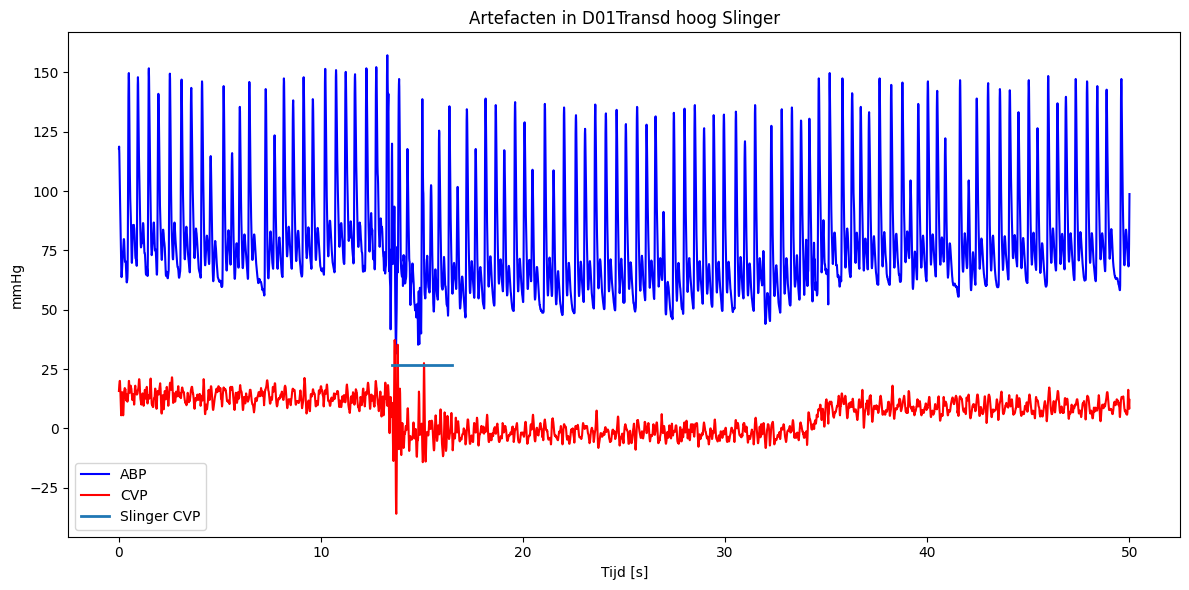

,Starttijd,Eindtijd,Naam van het artefact,Signaal
0,13.5,16.5,Slinger,CVP


In [6]:
path = r'C:\Users\Mila den Hollander\OneDrive - Delft University of Technology\Bureaublad\KT3405 Intensive care en computer simulatie\KT3401_AFdata_2025'
folder = 'Meerdere_artefacten'  # De mapnaam uit je eerdere screenshot [cite: 52]
filename = 'D01Transd_hoog_Slinger.xlsx'  # De bestandsnaam uit je eerdere screenshot [cite: 52]
fs = 100

beslisboom(path, folder, filename, fs=100)

